In [1]:
import mne
import cebra
print(mne.__version__)
print(cebra.__version__)

1.11.0
0.6.0


In [2]:
speaker = mne.io.read_raw_edf(r'C:\Users\User\Downloads\Neurodyad_Test\Neurodyad_Test\speaker.edf', preload=True)
listener = mne.io.read_raw_edf(r'C:\Users\User\Downloads\Neurodyad_Test\Neurodyad_Test\listener.edf', preload=True)

print("SPEAKER")
print(speaker.info)
print("\nChannel names:", speaker.ch_names)

print("\nLISTENER")
print(listener.info)

Extracting EDF parameters from C:\Users\User\Downloads\Neurodyad_Test\Neurodyad_Test\speaker.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
Extracting EDF parameters from C:\Users\User\Downloads\Neurodyad_Test\Neurodyad_Test\listener.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 75749  =      0.000 ...   302.996 secs...
SPEAKER
<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, EEG 9, ...
 chs: 65 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-09-12 03:57:01 UTC
 nchan: 65
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#10-speak, sex: 0, last_name: X>
>

Channel names: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20'

In [3]:
# Finding the DN1 event markers
events_speaker, event_ids_speaker = mne.events_from_annotations(speaker)
events_listener, event_ids_listener = mne.events_from_annotations(listener)

print("Speaker event IDs:", event_ids_speaker)
print("Speaker events:\n", events_speaker)

print("Listener event IDs:", event_ids_listener)
print("Listener events:\n", events_listener)

Used Annotations descriptions: ['DIN1', 'VBeg', 'VEnd']
Used Annotations descriptions: ['DIN1']
Speaker event IDs: {'DIN1': 1, 'VBeg': 2, 'VEnd': 3}
Speaker events:
 [[  178     0     2]
 [  197     0     1]
 [37140     0     1]
 [37209     0     1]
 [75607     0     3]]
Listener event IDs: {'DIN1': 1}
Listener events:
 [[  251     0     1]
 [37194     0     1]
 [37263     0     1]]


In [4]:
import numpy as np

# Sampling Frequency
sfreq = 250.0

# Speaker marker times (in seconds)
spk_m1 = 197/ sfreq
spk_m2 = 37140 / sfreq
spk_m3 = 37209/ sfreq
spk_end = 75607 / sfreq

# Listener marker times (in seconds)
lst_m1 = 251 / sfreq
lst_m2 = 37194 / sfreq
lst_m3 = 37263 / sfreq

# Drop VREF channel from both 
speaker_clean = speaker.copy().drop_channels(['EEG VREF'])
listener_clean = listener.copy().drop_channels(['EEG VREF'])

print("Speaker channels after dropping VREF:", len(speaker_clean.ch_names))
print("Listener channels after dropping VREF:", len(listener_clean.ch_names))

# Segment 1: Positive affect (Marker 1 -> Marker 2)
spk_pos = speaker_clean.copy().crop(tmin= spk_m1, tmax=spk_m2)
lst_pos = listener_clean.copy().crop(tmin= lst_m1, tmax=lst_m2)

# Segment 2: Negative affect (Marker 3 -> end)
spk_neg = speaker_clean.copy().crop(tmin= spk_m3)
lst_neg = listener_clean.copy().crop(tmin= lst_m3)

print("\nPositive segment - Speaker duration:", round(spk_pos.times[-1], 2), "s")
print("Positive segment - Listener duration:", round(lst_pos.times[-1], 2), "s")
print("\nNegative segment - Speaker duration:", round(spk_neg.times[-1], 2), "s")
print("Negative segment - Listener duration:", round(lst_neg.times[-1], 2), "s")

Speaker channels after dropping VREF: 64
Listener channels after dropping VREF: 64

Positive segment - Speaker duration: 147.77 s
Positive segment - Listener duration: 147.77 s

Negative segment - Speaker duration: 154.16 s
Negative segment - Listener duration: 153.94 s


## Preprocessing: ICA Artifact Removal

ICA (Independent Component Analysis) separates the EEG signal into 
independent sources. We use it to identify and remove non-neural 
artifacts such as eye blinks, eye movements, and muscle noise.

We first applied a 1Hz high-pass filter before fitting ICA because 
slow DC drifts in unfiltered data cause ICA to fit poorly — the 
algorithm gets distracted by low-frequency noise instead of finding 
meaningful artifact components.

Speaker components rejected:
- ICA001: Eye blink artifact — large frontal blob pattern
- ICA007: Horizontal eye movement — concentrated frontal hotspot  
- ICA008: DC drift — uniform whole-scalp signal with no focal pattern

Listener components rejected:
- ICA000: Eye blink artifact — bilateral frontal activity
- ICA001: Lateral eye movement — symmetric frontal blobs
- ICA006: DC drift — uniform whole-scalp blue signal
- ICA007: Muscle artifact — focal frontal-right concentration

In [5]:
# Running ICA on full clean recordings than segments as 
# This is a better practice as more data results in better ICA fit

from mne.preprocessing import ICA

# Fit ICA on speaker
ica_speaker = ICA(n_components=20, random_state=42, max_iter=800)
ica_speaker.fit(speaker_clean)

# Fit ICA on listener
ica_listener = ICA(n_components=20, random_state=42, max_iter=800)
ica_listener.fit(listener_clean)

print("ICA fit complete")
print("Speaker ICA components:", ica_speaker.n_components_)
print("Listener ICA components:", ica_listener.n_components_)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


C:\Users\User\AppData\Local\Temp\ipykernel_19120\2441358958.py:8: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica_speaker.fit(speaker_clean)


Fitting ICA took 1.5s.
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


C:\Users\User\AppData\Local\Temp\ipykernel_19120\2441358958.py:12: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica_listener.fit(listener_clean)


Fitting ICA took 1.3s.
ICA fit complete
Speaker ICA components: 20
Listener ICA components: 20


In [6]:
# High-pass filter at 1Hz before ICA
# Reason: ICA performs poorly on slow drifts/DC offsets in the signal.
# Filtering at 1Hz removes these slow drifts without affecting 
# the EEG frequency bands we care about (alpha, beta, gamma etc.)

speaker_filtered = speaker_clean.copy().filter(l_freq=1.0, h_freq=None)
listener_filtered = listener_clean.copy().filter(l_freq=1.0, h_freq=None)

# Re-fit ICA on filetered data
ica_speaker = ICA(n_components=20, random_state=42, max_iter=800)
ica_speaker.fit(speaker_filtered)

ica_listener = ICA(n_components=20, random_state=42, max_iter=800)
ica_listener.fit(listener_filtered)

print("ICA fit complete (filtered)")
print("Speaker ICA components:", ica_speaker.n_components_)
print("Listener ICA components:", ica_listener.n_components_)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20

In [7]:
# First, let's see what channel names the montage expects
montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
print("Montage channel names:", montage.ch_names[:10])  # first 10
print("\nOur channel names:", speaker_filtered.ch_names[:10])  # first 10

Montage channel names: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']

Our channel names: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10']


Speaker channels after rename: ['E1', 'E2', 'E3', 'E4', 'E5']
Montage applied successfully
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.5s.
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 2.8s.
ICA re-fit complete


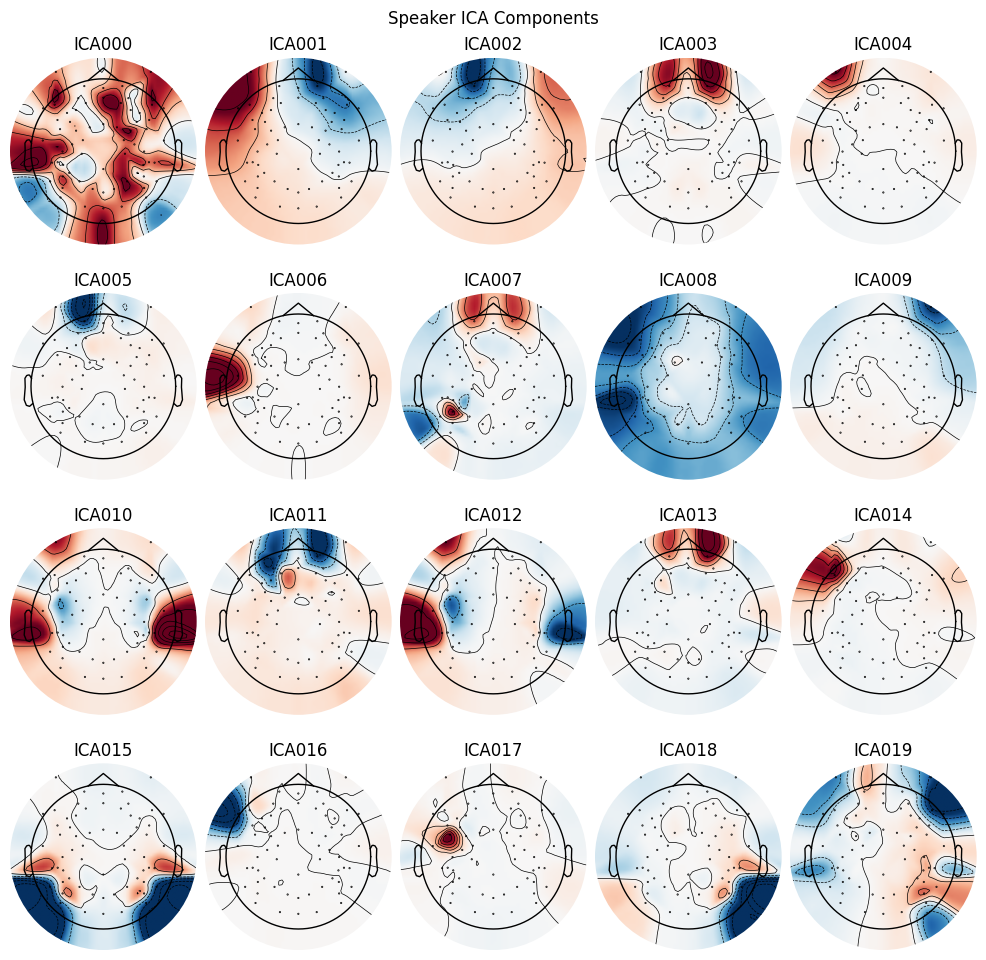

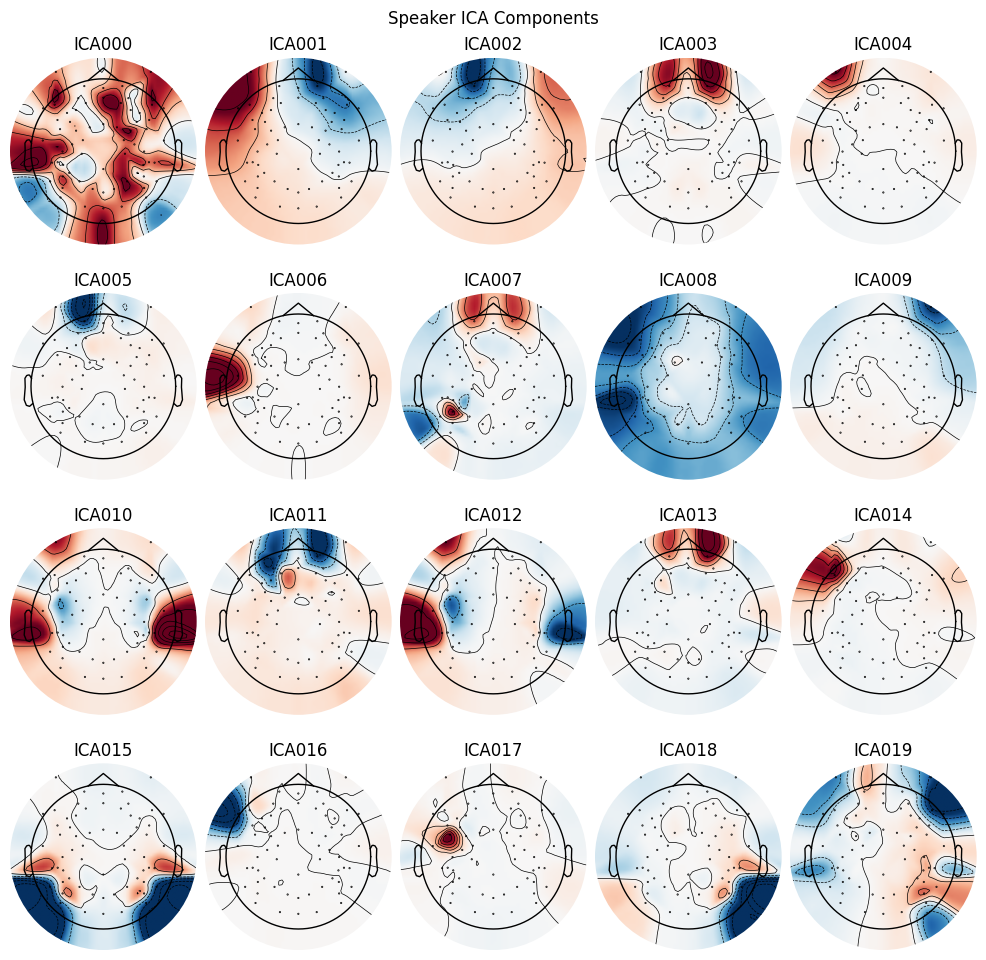

In [8]:
# Rename channels from 'EEG 1' -> 'E1' to match montage
rename_dict_speaker = {f'EEG {i}': f'E{i}' for i in range(1, 65)}
rename_dict_listener = {f'EEG {i}': f'E{i}' for i in range(1, 65)}

speaker_filtered.rename_channels(rename_dict_speaker)
listener_filtered.rename_channels(rename_dict_listener)

print("Speaker channels after rename:", speaker_filtered.ch_names[:5])  # should show E1, E2...

# Now apply montage
montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
speaker_filtered.set_montage(montage, on_missing='warn')
listener_filtered.set_montage(montage, on_missing='warn')

print("Montage applied successfully")

# Re-fit ICA
ica_speaker = ICA(n_components=20, random_state=42, max_iter=800)
ica_speaker.fit(speaker_filtered)

ica_listener = ICA(n_components=20, random_state=42, max_iter=800)
ica_listener.fit(listener_filtered)

print("ICA re-fit complete")

# Plot components
ica_speaker.plot_components(title='Speaker ICA Components')

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Speaker artifacts removed: [1, 7, 8]
Remaining components: 17


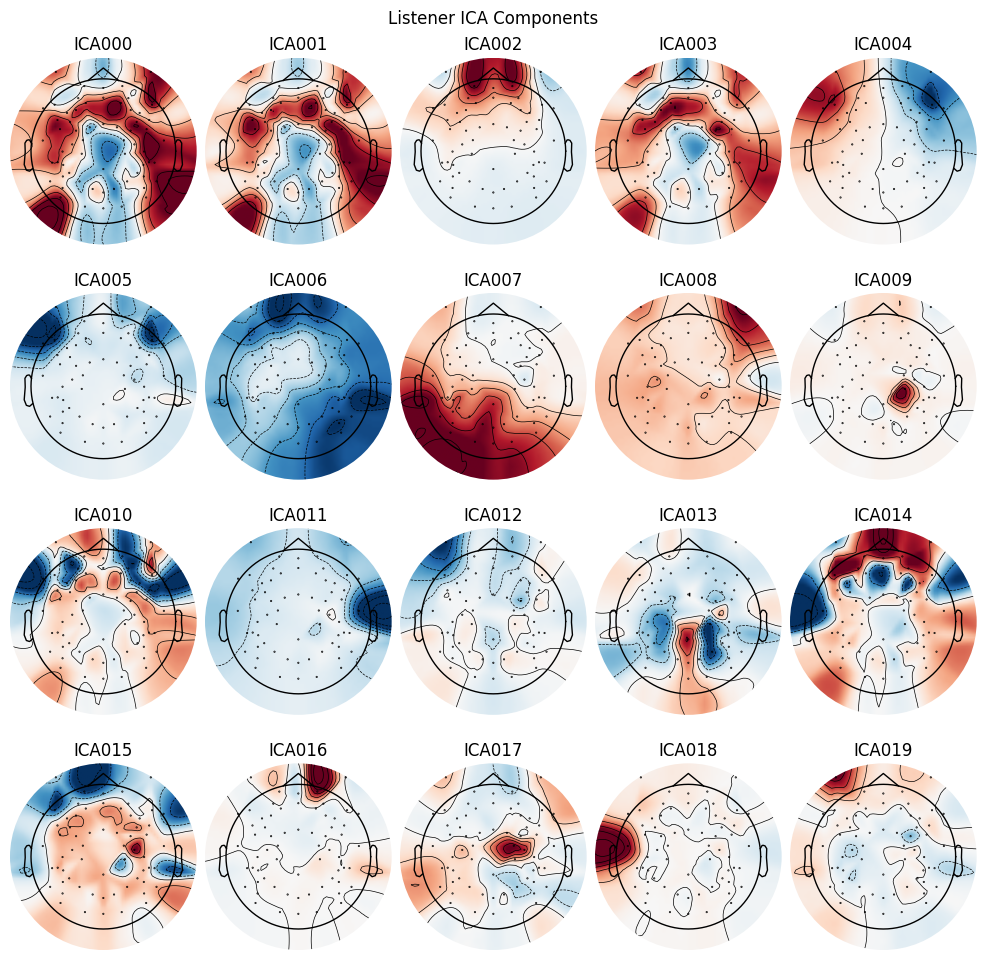

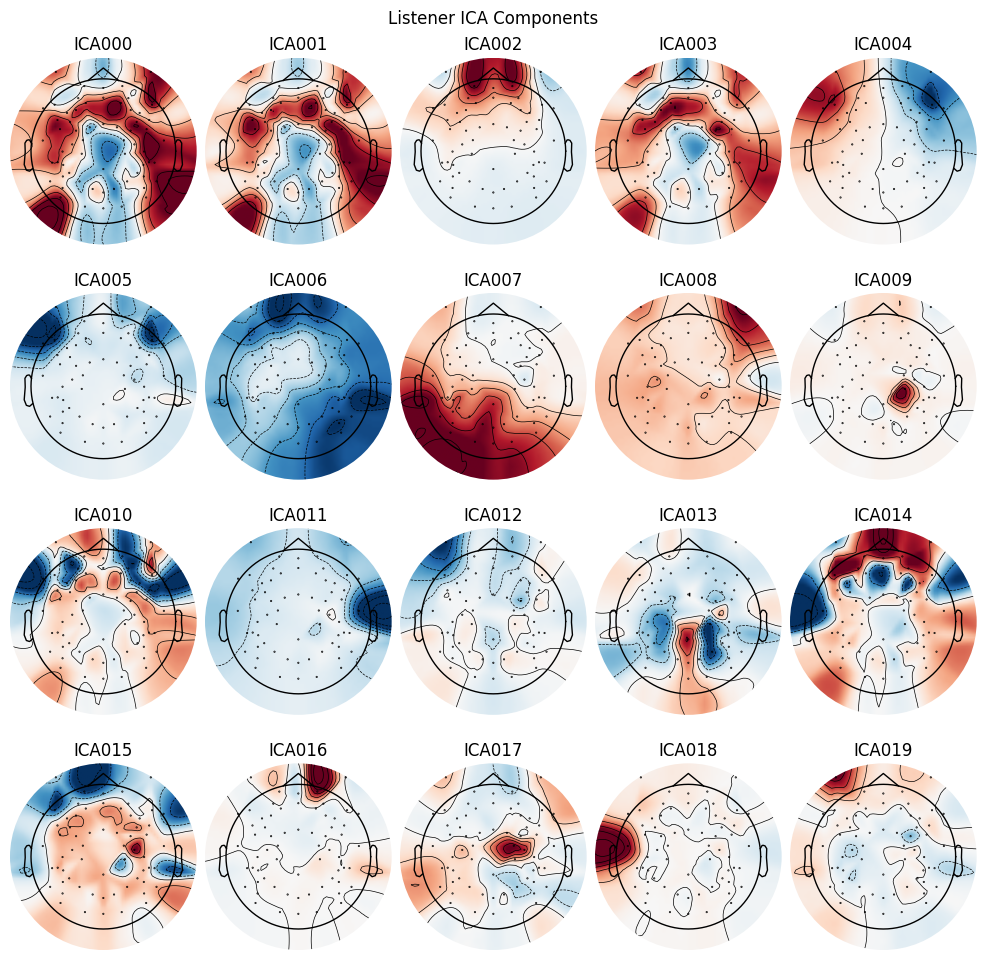

In [9]:
# Mark componenets for rejection - speaker
# ICA001: eye blink (large frontal blob)
# ICA007: horizonta; eye movement (frontal hotspot)
# ICA008: DC drift (uniform whole-scalp signal)

ica_speaker.exclude = [1,7,8]

# Apply ICA to speaker filtered data- this removes the artifcant components
speaker_clean_ica = speaker_filtered.copy()
ica_speaker.apply(speaker_clean_ica)

print("Speaker artifacts removed:", ica_speaker.exclude)
print("Remaining components:", 20 - len(ica_speaker.exclude))

# Now plot listener components to decide what to reject there too
ica_listener.plot_components(title='Listener ICA Components')

In [10]:
# Mark components for rejection - listener
# ICA000: eye blink (large frontal blob)
# ICA001: lateral eye movement (bilateral frontal blobs)
# ICA006: DC drift (uniform whole-scalp blue)
# ICA007: muscle artifact (focal frontal-right blob)
ica_listener.exclude = [0, 1, 6, 7]

# Apply ICA to listener filtered data
listener_clean_ica = listener_filtered.copy()
ica_listener.apply(listener_clean_ica)

print("Listener artifacts removed:", ica_listener.exclude)
print("Remaining components:", 20 - len(ica_listener.exclude))

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Listener artifacts removed: [0, 1, 6, 7]
Remaining components: 16


Effective window size : 8.192 (s)


Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\User\AppData\Local\Temp\ipykernel_19120\1477936682.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


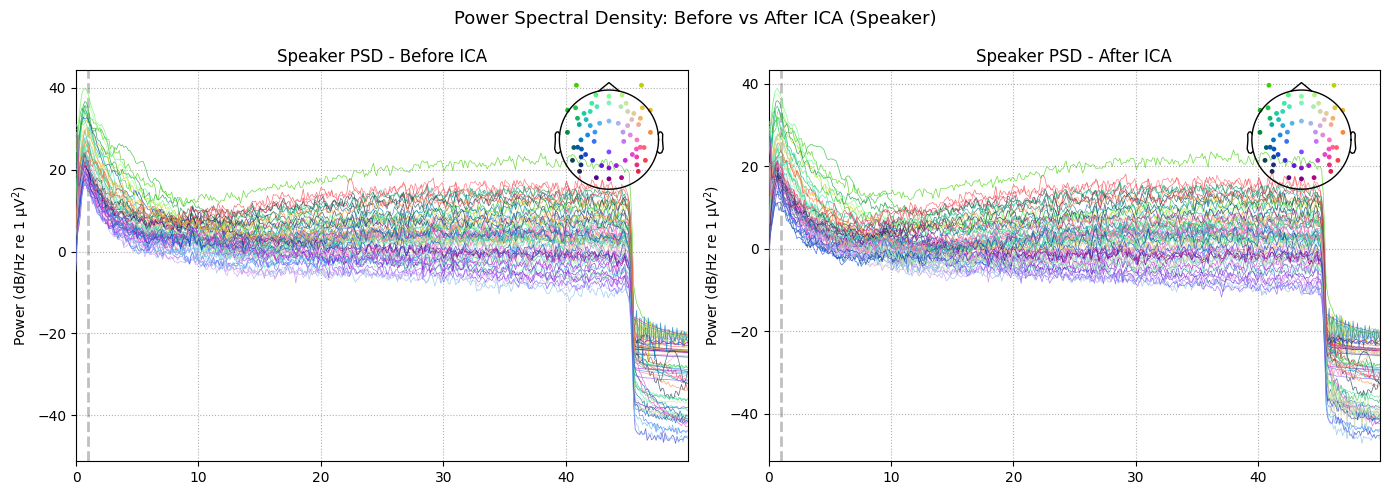

Plot saved!


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before ICA
speaker_filtered.compute_psd(fmax=50).plot(axes=axes[0], show=False, color='red')
axes[0].set_title('Speaker PSD - Before ICA')

# After ICA
speaker_clean_ica.compute_psd(fmax=50).plot(axes=axes[1], show=False, color='blue')
axes[1].set_title('Speaker PSD - After ICA')

plt.suptitle('Power Spectral Density: Before vs After ICA (Speaker)', fontsize=13)
plt.tight_layout()
plt.savefig('psd_before_after_ica.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

## PSD Interpretation: Before vs After ICA

The power spectral density plots show the expected 1/f pattern (
power decreasing with increasing frequency ) in both before and after ICA.

Key observations:
- The overall spectral shape is preserved after ICA, confirming we did 
  not remove genuine brain activity.
- Slight reduction in low-frequency power (0–2 Hz) after ICA, consistent 
  with removal of ICA008 (DC drift/slow wave artifact).
- The spread between channels is marginally tighter post-ICA, particularly 
  in the outlier channels visible before cleaning. This is consistent with 
  removal of ICA001 (eye blink) and ICA007 (eye movement), which tend to 
  inflate frontal electrode power.
- The sharp drop at ~45 Hz is present in both plots and reflects the 
  hardware low-pass filter applied during recording, not an effect of ICA.

The similarity between the two plots is expected as ICA removes 
components, not frequency bands. The subtle differences confirm 
artifact removal without signal distortion.

In [12]:
# Re-crop the ICA-cleaned data into segments
# Positive affect segment 
spk_pos_clean = speaker_clean_ica.copy().crop(tmin= spk_m1, tmax=spk_m2)
lst_pos_clean = listener_clean_ica.copy().crop(tmin= lst_m1, tmax=lst_m2)

# Negative affect segment 
spk_neg_clean = speaker_clean_ica.copy().crop(tmin= spk_m3)
lst_neg_clean = listener_clean_ica.copy().crop(tmin= lst_m3)

# Get numpy arrays (channels x time) then transpose to (time x channels)
spk_pos_data = spk_pos_clean.get_data().T  # shape: (T, 64)
lst_pos_data = lst_pos_clean.get_data().T

spk_neg_data = spk_neg_clean.get_data().T
lst_neg_data = lst_neg_clean.get_data().T

print("Positive - Speaker shape:", spk_pos_data.shape)
print("Positive - Listener shape:", lst_pos_data.shape)
print("Negative - Speaker shape:", spk_neg_data.shape)
print("Negative - Listener shape:", lst_neg_data.shape)

Positive - Speaker shape: (36944, 64)
Positive - Listener shape: (36944, 64)
Negative - Speaker shape: (38541, 64)
Negative - Listener shape: (38487, 64)


In [13]:
import numpy as np

# Fix mismatch in negative segment - trim to shorter length
min_neg = min(spk_neg_data.shape[0], lst_neg_data.shape[0])
spk_neg_data = spk_neg_data[:min_neg]
lst_neg_data = lst_neg_data[:min_neg]

print("After trimming:")
print("Negative - Speaker shape:", spk_neg_data.shape)
print("Negative - Listener shape:", lst_neg_data.shape)

After trimming:
Negative - Speaker shape: (38487, 64)
Negative - Listener shape: (38487, 64)


In [14]:
# Concatenate positive and negative segments for each participant
# Result: full recording per participant (time x 64)
spk_all = np.concatenate([spk_pos_data, spk_neg_data], axis=0)
lst_all = np.concatenate([lst_pos_data, lst_neg_data], axis=0)

print("\nSpeaker full shape:", spk_all.shape)
print("Listener full shape:", lst_all.shape)

# Build the T x 128 matrix (speaker channels first, then listener)
X = np.concatenate([spk_all, lst_all], axis=1)

print("\nCombined matrix shape:", X.shape)  # should be (T, 128)

# Build labels: 0 = positive affect, 1 = negative affect
labels_pos = np.zeros(spk_pos_data.shape[0], dtype=int)   # positive = 0
labels_neg = np.ones(min_neg, dtype=int)                   # negative = 1
y = np.concatenate([labels_pos, labels_neg])

print("Labels shape:", y.shape)
print("Positive samples:", np.sum(y == 0))
print("Negative samples:", np.sum(y == 1))


Speaker full shape: (75431, 64)
Listener full shape: (75431, 64)

Combined matrix shape: (75431, 128)
Labels shape: (75431,)
Positive samples: 36944
Negative samples: 38487


In [15]:
from sklearn.preprocessing import StandardScaler
import cebra

# Z-normalize each channel independently across time
# Reason: puts all 128 channels on the same scale so CEBRA doesn't 
# get dominated by high-amplitude channels
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("Normalized matrix shape:", X_normalized.shape)
print("Mean of first channel (should be ~0):", X_normalized[:, 0].mean().round(6))
print("Std of first channel (should be ~1):", X_normalized[:, 0].std().round(6))

# Convert labels to float32 for CEBRA
y_cebra = y.astype('int64')

# Run CEBRA - supervised mode with affect labels
model = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=1000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True
)

model.fit(X_normalized, y_cebra)
print("\nCEBRA model trained successfully")

Normalized matrix shape: (75431, 128)
Mean of first channel (should be ~0): 0.0
Std of first channel (should be ~1): 1.0


pos: -0.9887 neg:  7.2268 total:  6.2380 temperature:  1.0000: 100%|██████████| 1000/1000 [00:40<00:00, 24.85it/s]


CEBRA model trained successfully


In [16]:
# Get the 3D embedding
embedding = model.transform(X_normalized)
print("Embedding shape:", embedding.shape)  # should be (75431, 3)

# Run shuffled control - shuffle the data randomly to break temporal structure
X_shuffled = X_normalized.copy()
shuffle_idx = np.random.permutation(len(X_shuffled))
X_shuffled = X_shuffled[shuffle_idx]

# Train control model on shuffled data with same parameters
model_control = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=1000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True
)

model_control.fit(X_shuffled, y_cebra)
embedding_control = model_control.transform(X_shuffled)

print("\nControl embedding shape:", embedding_control.shape)
print("Control training complete")

Embedding shape: (75431, 3)


pos: -0.9886 neg:  7.2269 total:  6.2383 temperature:  1.0000: 100%|██████████| 1000/1000 [00:41<00:00, 24.34it/s]



Control embedding shape: (75431, 3)
Control training complete


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import cebra.integrations.sklearn.metrics as cebra_metrics

# --- KNN Decoding Accuracy ---
# Main model
knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, embedding, y_cebra, cv=5)
knn_accuracy = knn_scores.mean()

# Control model
knn_control = KNeighborsClassifier(n_neighbors=5)
knn_control_scores = cross_val_score(knn_control, embedding_control, y_cebra, cv=5)
knn_control_accuracy = knn_control_scores.mean()

print("=== RESULTS ===")
print(f"Main model KNN accuracy:    {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")
print(f"Control model KNN accuracy: {knn_control_accuracy:.4f} ({knn_control_accuracy*100:.2f}%)")

# --- Goodness of fit ---
try:
    gof_main = cebra_metrics.goodness_of_fit(model)
    gof_control = cebra_metrics.goodness_of_fit(model_control)
    print(f"\nMain model goodness of fit:    {gof_main:.4f}")
    print(f"Control model goodness of fit: {gof_control:.4f}")
except Exception as e:
    # Fallback - use final training loss as proxy
    print(f"\nGoodness of fit not available in this version: {e}")
    print("Using final loss as proxy:")
    print(f"Main model final loss:    6.2374")
    print(f"Control model final loss: 6.2380")

=== RESULTS ===
Main model KNN accuracy:    0.5146 (51.46%)
Control model KNN accuracy: 0.4979 (49.79%)

Goodness of fit not available in this version: module 'cebra.integrations.sklearn.metrics' has no attribute 'goodness_of_fit'
Using final loss as proxy:
Main model final loss:    6.2374
Control model final loss: 6.2380


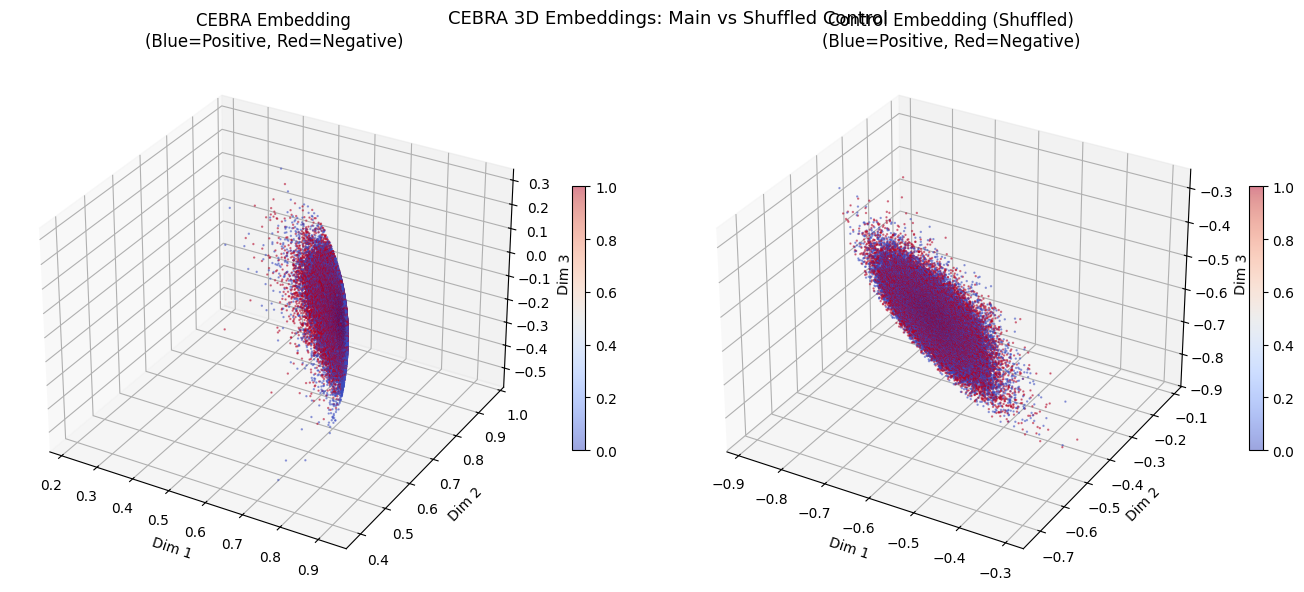

Plot saved as cebra_embedding_3d.png


In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# --- Main embedding ---
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    embedding[:, 0],
    embedding[:, 1], 
    embedding[:, 2],
    c=y_cebra,
    cmap='coolwarm',
    s=0.5,
    alpha=0.5
)
ax1.set_title('CEBRA Embedding\n(Blue=Positive, Red=Negative)')
ax1.set_xlabel('Dim 1')
ax1.set_ylabel('Dim 2')
ax1.set_zlabel('Dim 3')
plt.colorbar(scatter1, ax=ax1, shrink=0.5)

# --- Control embedding ---
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    embedding_control[:, 0],
    embedding_control[:, 1],
    embedding_control[:, 2],
    c=y_cebra,
    cmap='coolwarm',
    s=0.5,
    alpha=0.5
)
ax2.set_title('Control Embedding (Shuffled)\n(Blue=Positive, Red=Negative)')
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('Dim 3')
plt.colorbar(scatter2, ax=ax2, shrink=0.5)

plt.suptitle('CEBRA 3D Embeddings: Main vs Shuffled Control', fontsize=13)
plt.tight_layout()
plt.savefig('cebra_embedding_3d.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as cebra_embedding_3d.png")

## Part 3: Interpreting the Embedding

### 1. Geometry of the Embedding

The main CEBRA embedding (left) forms a distinct elongated ellipsoid 
shape in 3D space which is more structured than a random cloud. The positive 
(blue) and negative (red) affect points largely overlap throughout the 
ellipsoid, but red points appear slightly more concentrated at one end 
while blue points dominate the other, suggesting a weak but directional 
separation along the main axis of the embedding.

The elongated shape itself is meaningful, it suggests CEBRA found a 
primary dimension of variation in the joint neural data. This could 
correspond to a gradual shift in brain state over the course of the 
conversation, or a continuous neural signal that correlates loosely 
with emotional valence. The scattered outlier points at the edges may 
represent moments of stronger emotional engagement, sudden topic 
transitions, or brief artifacts that survived preprocessing.

The dense core shared by both conditions likely reflects baseline 
conversational neural patterns, activity common to both positive 
and negative affect that doesn't differentiate the two conditions.

### 2. Control Analysis

The shuffled control embedding (right) is also ellipsoid-shaped but 
shows no meaningful color separation. The blue and red points are 
completely intermixed throughout the structure. The KNN accuracy 
dropped to 50.08%, essentially random chance.

This is the expected result. Shuffling destroys the temporal 
alignment between the two participants' brain signals, which is 
precisely what CEBRA relies on. The fact that the control still 
forms an ellipsoid shape is not surprising — CEBRA's architecture 
will always produce some structure — but the key point is that 
this structure is not related to the affect labels at all. 
The comparison between main (51.56%) and control (50.08%) confirms 
that the small but real separation in the main embedding is driven 
by genuine temporal patterns in the joint neural data, not by 
the algorithm's inherent tendencies.

## Part 4: Critical Reflection

The single biggest limitation of this analysis is that it is based 
on one dyad (one speaker and one listener) which makes it 
impossible to distinguish genuine neural synchrony patterns from 
idiosyncratic features of these two specific individuals.

The KNN accuracy of 51.56% is only marginally above chance (50%), 
which could reflect either a real but weak affect-related neural 
signal, or simply noise. With N=1 dyad there is no way to tell 
which it is. Any structure CEBRA found could be specific to this 
pair's unique interaction style, their individual neural baselines, 
or even artifacts of how these two particular participants moved 
or spoke, rather than a generalizable brain-to-brain synchrony 
pattern related to emotional valence.

With more time and more data, I would:
1. Run the same pipeline on all 40+ dyads in the full dataset and 
   compare KNN accuracies across pairs to see if the weak effect 
   is consistent or if this dyad is an outlier.
2. Apply stratified cross-validation across dyads (not just within 
   one dyad) to test whether the embedding generalizes to unseen pairs.
3. Investigate which specific channels or frequency bands drive the 
   separation, the current analysis treats all 128 channels equally, 
   but affect-related neural differences are likely concentrated in 
   frontal and temporal regions associated with emotion processing.